# Detecção de anomalias em transações Bitcoin

Pipeline de processamento em lote sobre arquitetura medalhão no BigQuery, com
K-Means treinado em BigQuery ML para identificar transações estruturalmente
atípicas. Recorte de 2020: **112.553.498 transações** em 53.222 blocos.

Todo o processamento e toda a modelagem estão escritos em SQL. Este notebook
apresenta os **resultados**: executa apenas as consultas de leitura, sobre as
tabelas e modelos já materializados.

As seções seguem a **numeração das consultas salvas do projeto** — 25, 27, 30, 31,
32 e 34 — que é a mesma ordem do pipeline.

## 1. Ambiente
Se uma consulta exceder o teto de faturamento, o BigQuery a recusa *antes*
de processar.

In [ ]:
from google.cloud import bigquery
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

cliente = bigquery.Client()

TETO_BYTES = 50 * 1024**3   # 50 GB por consulta

def executar(sql, rotulo=""):
    """Executa uma consulta de leitura e devolve o resultado como DataFrame."""
    job = cliente.query(sql, job_config=bigquery.QueryJobConfig(
        maximum_bytes_billed=TETO_BYTES))
    df = job.result().to_dataframe()
    gb = (job.total_bytes_billed or 0) / 1024**3
    print(f"{rotulo}  {len(df)} linhas  |  {gb:.2f} GB faturados")
    return df

print(f"projeto: {cliente.project}  |  teto por consulta: {TETO_BYTES / 1024**3:.0f} GB")

projeto: trabalho1-pdm-2026  |  teto por consulta: 50 GB


In [ ]:
# Paleta e estilo dos graficos.
SERIE   = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
TINTA   = "#52514e"
CRITICO = "#d03b3b"
DIVERGENTE = ["#184f95", "#f0efec", "#d03b3b"]   # azul <-> vermelho

mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": TINTA,
    "axes.titlecolor": "#0b0b0b", "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlepad": 12, "axes.labelsize": 9, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2.0, "lines.markersize": 8,
    "font.size": 10, "figure.dpi": 110,
})
print("estilo aplicado")

estilo aplicado


## 2. Escolha de K — consulta 25

Sete modelos treinados: cinco valores de K sobre amostra de 1%, mais o K=8 em três
tamanhos de amostra. `ML.EVALUATE` lê estatísticas do próprio modelo.

In [ ]:
SQL_25 = """
SELECT 'K=3  | amostra 1%'   AS modelo, 3  AS k, '1%'   AS amostra,
       ROUND(davies_bouldin_index, 4) AS davies_bouldin,
       ROUND(mean_squared_distance, 4) AS dist_quadratica
FROM ML.EVALUATE(MODEL `gold.kmeans_k3`)
UNION ALL
SELECT 'K=5  | amostra 1%', 5, '1%',
       ROUND(davies_bouldin_index, 4), ROUND(mean_squared_distance, 4)
FROM ML.EVALUATE(MODEL `gold.kmeans_k5`)
UNION ALL
SELECT 'K=6  | amostra 1%', 6, '1%',
       ROUND(davies_bouldin_index, 4), ROUND(mean_squared_distance, 4)
FROM ML.EVALUATE(MODEL `gold.kmeans_k6`)
UNION ALL
SELECT 'K=8  | amostra 1%', 8, '1%',
       ROUND(davies_bouldin_index, 4), ROUND(mean_squared_distance, 4)
FROM ML.EVALUATE(MODEL `gold.kmeans_k8_1pct`)
UNION ALL
SELECT 'K=12 | amostra 1%', 12, '1%',
       ROUND(davies_bouldin_index, 4), ROUND(mean_squared_distance, 4)
FROM ML.EVALUATE(MODEL `gold.kmeans_k12`)
UNION ALL
SELECT 'K=8  | amostra 10%', 8, '10%',
       ROUND(davies_bouldin_index, 4), ROUND(mean_squared_distance, 4)
FROM ML.EVALUATE(MODEL `gold.kmeans_k8_10pct`)
UNION ALL
SELECT 'K=8  | base completa', 8, '100%',
       ROUND(davies_bouldin_index, 4), ROUND(mean_squared_distance, 4)
FROM ML.EVALUATE(MODEL `gold.kmeans_k8_full`)
ORDER BY davies_bouldin;
"""

selecao = executar(SQL_25, "[25] selecao de K")
display(selecao)

[25] selecao de K  7 linhas  |  0.00 GB faturados


,modelo,k,amostra,davies_bouldin,dist_quadratica
0,K=8 | amostra 10%,8,10%,1.6050,11.5671
1,K=5 | amostra 1%,5,1%,1.6471,14.1931
2,K=8 | amostra 1%,8,1%,1.7576,13.1583
3,K=12 | amostra 1%,12,1%,1.7733,10.2628
4,K=8 | base completa,8,100%,1.8780,12.2222
5,K=6 | amostra 1%,6,1%,2.1067,14.8011
6,K=3 | amostra 1%,3,1%,3.3682,18.3840


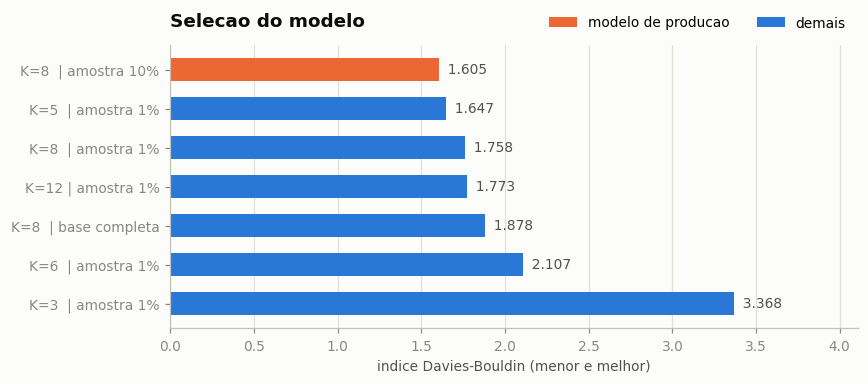

In [ ]:
# Davies-Bouldin: menor e melhor. Uma so medida no eixo -- a distancia quadratica fica na tabela acima
d = selecao.sort_values("davies_bouldin", ascending=False).reset_index(drop=True)
cores = [SERIE[1] if a == "10%" else SERIE[0] for a in d["amostra"]]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(d["modelo"], d["davies_bouldin"], height=0.6, color=cores)
for y, v in enumerate(d["davies_bouldin"]):
    ax.text(v, y, f"  {v:.3f}", va="center", ha="left", fontsize=9, color=TINTA)

ax.set_xlabel("indice Davies-Bouldin (menor e melhor)")
ax.set_title("Selecao do modelo", loc="left")
ax.set_xlim(0, d["davies_bouldin"].max() * 1.22)
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)
ax.legend(handles=[Patch(facecolor=SERIE[1], label="modelo de producao"),
                   Patch(facecolor=SERIE[0], label="demais")],
          loc="lower right", bbox_to_anchor=(1, 1.01), ncol=2)
plt.tight_layout()
plt.show()

O resultado contraintuitivo do trabalho está aqui: treinar com a **base completa
não** produziu a melhor clusterização. O K-Means é sensível à inicialização, e mais
volume de treino não melhora monotonicamente o agrupamento. Por isso o modelo de
produção é o treinado sobre 10%, e não o de 100%.

## 3. O que cada cluster é — consulta 27

`ML.CENTROIDS` lê do modelo, sem varrer tabela.

[27] centroides  168 linhas  |  0.01 GB faturados


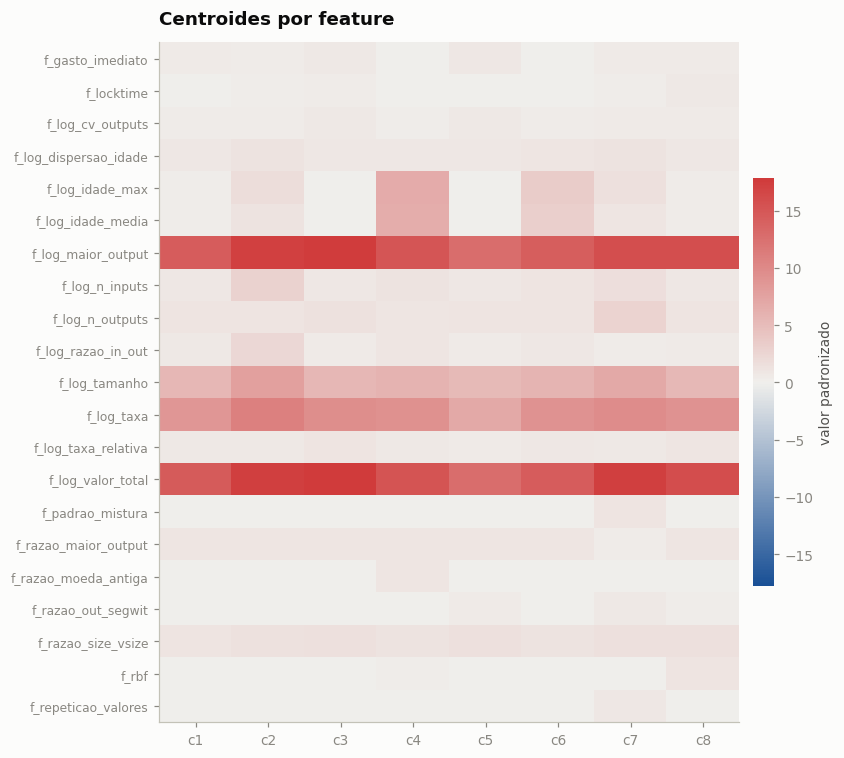

In [ ]:
SQL_27 = """
SELECT
  centroid_id,
  feature,
  ROUND(numerical_value, 3) AS valor
FROM ML.CENTROIDS(MODEL `gold.kmeans_k8_10pct`)
ORDER BY centroid_id, feature;
"""

centroides = executar(SQL_27, "[27] centroides")
matriz = centroides.pivot(index="feature", columns="centroid_id", values="valor")
lim = float(matriz.abs().max().max())

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(matriz.values, aspect="auto", vmin=-lim, vmax=lim,
               cmap=mpl.colors.LinearSegmentedColormap.from_list("div", DIVERGENTE))
ax.set_xticks(range(matriz.shape[1]))
ax.set_xticklabels([f"c{c}" for c in matriz.columns])
ax.set_yticks(range(matriz.shape[0]))
ax.set_yticklabels(matriz.index, fontsize=8)
ax.set_title("Centroides por feature", loc="left")
ax.grid(visible=False)

cb = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cb.set_label("valor padronizado", fontsize=9, color=TINTA)
cb.outline.set_visible(False)
plt.tight_layout()
plt.show()

As features entram no modelo padronizadas, então **zero é a média** e a escala é
divergente: azul abaixo da média, vermelho acima, cinza neutro no meio. Cada coluna
é o retrato de um comportamento.

## 4. Onde cortar — consulta 30

In [ ]:
SQL_30 = """
SELECT
  ROUND(APPROX_QUANTILES(normalized_distance, 1000)[OFFSET(500)], 3) AS p50,
  ROUND(APPROX_QUANTILES(normalized_distance, 1000)[OFFSET(900)], 3) AS p90,
  ROUND(APPROX_QUANTILES(normalized_distance, 1000)[OFFSET(950)], 3) AS p95,
  ROUND(APPROX_QUANTILES(normalized_distance, 1000)[OFFSET(990)], 3) AS p99,
  ROUND(APPROX_QUANTILES(normalized_distance, 1000)[OFFSET(999)], 3) AS p999,
  ROUND(MAX(normalized_distance), 3)                                 AS maximo,
  COUNTIF(normalized_distance >= 5)                                  AS acima_5,
  COUNTIF(normalized_distance >= 10)                                 AS acima_10,
  COUNTIF(normalized_distance >= 20)                                 AS acima_20
FROM `gold.anomaly_scores`
WHERE DATE(block_timestamp) BETWEEN DATE '2020-01-01' AND DATE '2020-12-31';
"""

dist = executar(SQL_30, "[30] distribuicao das distancias")
display(dist)

[30] distribuicao das distancias  1 linhas  |  1.68 GB faturados


,p50,p90,p95,p99,p999,maximo,acima_5,acima_10,acima_20
0,0.847,1.187,1.347,1.686,2.258,5.256,9,0,0


/tmp/ipykernel_864/2961028282.py:26: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  a2.set_xlim(min(contagens) / 4, max(contagens) * 4)


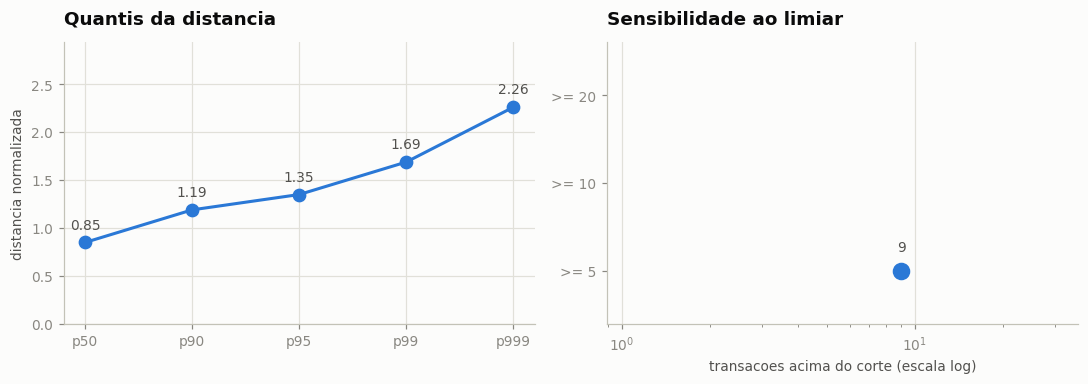

In [ ]:
r = dist.iloc[0]
quantis = ["p50", "p90", "p95", "p99", "p999"]
valores = [float(r[q]) for q in quantis]
cortes = [(">= 5", r["acima_5"]), (">= 10", r["acima_10"]), (">= 20", r["acima_20"])]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))

a1.plot(quantis, valores, marker="o", color=SERIE[0])
for x, v in zip(quantis, valores):
    a1.annotate(f"{v:.2f}", (x, v), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=9, color=TINTA)
a1.set_ylabel("distancia normalizada")
a1.set_title("Quantis da distancia", loc="left")
a1.set_ylim(0, max(valores) * 1.3)

contagens = [float(c[1]) for c in cortes]
a2.scatter(contagens, [c[0] for c in cortes], s=110, color=SERIE[0],
           zorder=3, clip_on=False)
for y, v in enumerate(contagens):
    a2.annotate(f"{int(v):,}", (v, y), textcoords="offset points", xytext=(0, 13),
                ha="center", fontsize=9, color=TINTA)
a2.set_xscale("log")
a2.set_xlim(min(contagens) / 4, max(contagens) * 4)
a2.set_ylim(-0.6, len(cortes) - 0.4)
a2.set_xlabel("transações acima do corte (escala log)")
a2.set_title("Sensibilidade ao limiar", loc="left")
a2.grid(axis="y", visible=False)
a2.set_axisbelow(True)

plt.tight_layout()
plt.show()

O `contamination = 0.01` de `ML.DETECT_ANOMALIES` é um **percentil de corte, não
uma estimativa do modelo**: ele define por construção que 1% das transações será
sinalizado. Por isso `gold.anomaly_scores` preserva a `normalized_distance` — com
ela dá para reavaliar qualquer outro limiar sem reprocessar nada, que é exatamente
o que o painel da direita mostra.

## 5. O modelo encontra o que já sabemos ser incomum — consulta 31

Cruza `gold.anomaly_scores` com `silver.tx_enriched` no ano completo.

In [ ]:
SQL_31 = """
WITH scores AS (
  SELECT transaction_hash, is_anomaly
  FROM `gold.anomaly_scores`
  WHERE DATE(block_timestamp) BETWEEN DATE '2020-01-01' AND DATE '2020-12-31'
),
heuristicas AS (
  SELECT
    transaction_hash,
    n_outputs >= 10 AND out_valores_distintos <= 2 AS repeticao_valores,
    idade_max_dias > 1825                          AS moeda_dormente,
    n_outputs >= 100                               AS muitos_outputs,
    n_inputs  >= 100                               AS muitos_inputs
  FROM `silver.tx_enriched`
  WHERE DATE(block_timestamp) BETWEEN DATE '2020-01-01' AND DATE '2020-12-31'
    AND NOT is_coinbase
),
j AS (
  SELECT h.*, s.is_anomaly
  FROM heuristicas h JOIN scores s USING (transaction_hash)
)
SELECT
  'Alta repeticao de valores (>= 10 outputs, <= 2 valores distintos)' AS heuristica,
  COUNTIF(repeticao_valores)                     AS selecionadas_pela_regra,
  COUNTIF(repeticao_valores AND is_anomaly)      AS tambem_marcadas_pelo_modelo,
  ROUND(100 * SAFE_DIVIDE(COUNTIF(repeticao_valores AND is_anomaly), COUNTIF(repeticao_valores)), 1) AS pct_concordancia
FROM j
UNION ALL
SELECT
  'Moeda dormente (UTXO gasto com mais de 5 anos)',
  COUNTIF(moeda_dormente),
  COUNTIF(moeda_dormente AND is_anomaly),
  ROUND(100 * SAFE_DIVIDE(COUNTIF(moeda_dormente AND is_anomaly), COUNTIF(moeda_dormente)), 1)
FROM j
UNION ALL
SELECT
  'Alta contagem de outputs (>= 100)',
  COUNTIF(muitos_outputs),
  COUNTIF(muitos_outputs AND is_anomaly),
  ROUND(100 * SAFE_DIVIDE(COUNTIF(muitos_outputs AND is_anomaly), COUNTIF(muitos_outputs)), 1)
FROM j
UNION ALL
SELECT
  'Alta contagem de inputs (>= 100)',
  COUNTIF(muitos_inputs),
  COUNTIF(muitos_inputs AND is_anomaly),
  ROUND(100 * SAFE_DIVIDE(COUNTIF(muitos_inputs AND is_anomaly), COUNTIF(muitos_inputs)), 1)
FROM j
UNION ALL
SELECT
  'Baseline: todas as transacoes',
  COUNT(*),
  COUNTIF(is_anomaly),
  ROUND(100 * SAFE_DIVIDE(COUNTIF(is_anomaly), COUNT(*)), 1)
FROM j
ORDER BY pct_concordancia DESC;
"""

padroes = executar(SQL_31, "[31] alinhamento com heuristicas")
display(padroes)

[31] alinhamento com heuristicas  5 linhas  |  19.07 GB faturados


,heuristica,selecionadas_pela_regra,tambem_marcadas_pelo_modelo,pct_concordancia
0,Alta contagem de outputs (>= 100),80580,72215,89.6
1,Alta contagem de inputs (>= 100),313954,124842,39.8
2,Moeda dormente (UTXO gasto com mais de 5 anos),27505,2863,10.4
3,"Alta repeticao de valores (>= 10 outputs, <= 2...",43619,1641,3.8
4,Baseline: todas as transacoes,112500276,1119290,1.0


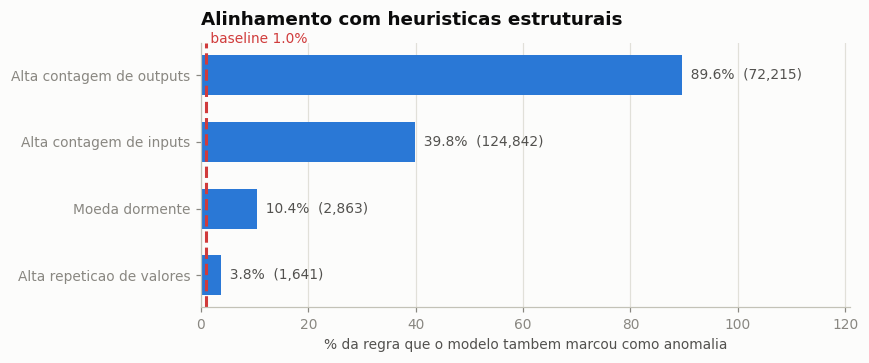

In [ ]:
base = padroes[padroes["heuristica"].str.startswith("Baseline")]
alvos = padroes[~padroes["heuristica"].str.startswith("Baseline")].sort_values(
    "pct_concordancia")
taxa_base = float(base["pct_concordancia"].iloc[0])

rotulos = alvos["heuristica"].str.split(" (", regex=False).str[0]

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(rotulos, alvos["pct_concordancia"], height=0.6, color=SERIE[0])
for y, (v, n) in enumerate(zip(alvos["pct_concordancia"],
                               alvos["tambem_marcadas_pelo_modelo"])):
    ax.text(v, y, f"  {v:.1f}%  ({n:,.0f})", va="center", ha="left",
            fontsize=9, color=TINTA)

ax.axvline(taxa_base, color=CRITICO, linewidth=2, linestyle="--")
ax.text(taxa_base, len(alvos) - 0.35, f" baseline {taxa_base:.1f}%",
        color=CRITICO, fontsize=9, va="top")

ax.set_xlabel("% da regra que o modelo tambem marcou como anomalia")
ax.set_title("Alinhamento com heuristicas estruturais", loc="left")
ax.set_xlim(0, max(alvos["pct_concordancia"].max(), taxa_base) * 1.35)
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

O modelo é não supervisionado: nunca
viu um rótulo e nenhuma dessas heurísticas foi dada a ele. Mesmo assim sinaliza
transações que as regras estruturais reconhecem como atípicas a taxas muito acima
da linha de base de 1% de todas as transações.

As duas linhas metodologicamente mais limpas são **moeda dormente** e **repetição
de valores**, porque as outras compartilham grandezas com features do modelo — a
contagem de inputs e de outputs entra na matriz, então concordância ali é menos
independente do que parece.

## 6. As maiores anomalias do ano — consulta 32

In [ ]:
SQL_32 = """
SELECT
  s.transaction_hash,
  DATE(s.block_timestamp)            AS dia,
  ROUND(s.normalized_distance, 2)    AS distancia,
  s.centroid_id,
  t.n_inputs,
  t.n_outputs,
  ROUND(t.out_total / 100000000, 4)  AS btc_total,
  t.idade_max_dias,
  ROUND(t.fee_por_vbyte, 1)          AS fee_vbyte
FROM `gold.anomaly_scores` s
JOIN `silver.tx_enriched` t USING (transaction_hash)
WHERE DATE(s.block_timestamp) BETWEEN DATE '2020-01-01' AND DATE '2020-12-31'
  AND DATE(t.block_timestamp) BETWEEN DATE '2020-01-01' AND DATE '2020-12-31'
  AND s.is_anomaly
ORDER BY s.normalized_distance DESC
LIMIT 20;
"""

display(executar(SQL_32, "[32] maiores anomalias"))

[32] maiores anomalias  20 linhas  |  23.16 GB faturados


,transaction_hash,dia,distancia,centroid_id,n_inputs,n_outputs,btc_total,idade_max_dias,fee_vbyte
0,88f4566f805ef495807c398e456c1a2dbafa9ee2c668eb...,2020-08-15,5.26,2,829,101,8.168200000,2,96.200000000
1,04bb5cac5f9744dbc768635be49313d242613405dffbf5...,2020-09-27,5.23,2,957,72,8.838700000,1,65.200000000
2,fff164c112339e28d63eb658b582629562a676369175a8...,2020-08-15,5.10,2,709,101,3.182800000,3,96.200000000
3,d680e2c5f7f10261a73c1fbb51f1a952fb4d2eaf6cc6ff...,2020-06-03,5.10,2,874,42,11.444500000,5,71.600000000
4,873354ab4b89624ba5d5cf002e8e224cde8ecf20f7d71c...,2020-12-22,5.06,2,595,4,9.000000000,6,30.000000000
5,b2dcf2969ec9fb3203b0f71ab2dd532458457f83ab4d32...,2020-05-20,5.02,2,948,4,29.539000000,1,116.000000000
6,1fd3982aa5bfa8b878e61159befb11c13a1ce34069db0a...,2020-10-01,5.01,2,889,211,25.409300000,13,100.700000000
7,0d5540875c5e5bc4e58a6299874f71e0a811f59b5f7066...,2020-10-09,5.01,2,867,60,2.674000000,5,105.900000000
8,ff47578f9f6395ba46b0f9d8776a8796f9c37574736563...,2020-07-09,5.00,2,788,101,3.797100000,4,44.100000000
9,6fc1fa94a292ff5b58719ba3ee117df925743c7ca05264...,2020-07-23,5.00,2,946,10,3.775200000,4,111.500000000


## 7. Do score para a fila de trabalho — consulta 34

In [ ]:
SQL_34 = """
SELECT
  prioridade,
  COUNT(*) AS transacoes,
  ROUND(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 3) AS pct,
  ROUND(MIN(normalized_distance), 3) AS dist_min,
  ROUND(MAX(normalized_distance), 3) AS dist_max
FROM `gold.v_anomaly_priority`
WHERE DATE(block_timestamp) BETWEEN DATE '2020-01-01' AND DATE '2020-12-31'
GROUP BY prioridade
ORDER BY dist_min DESC;
"""

prioridade = executar(SQL_34, "[34] priorizacao")
display(prioridade)

[34] priorizacao  4 linhas  |  1.68 GB faturados


,prioridade,transacoes,pct,dist_min,dist_max
0,alta,12472,0.011,3.000,5.256
1,media,103088,0.092,2.241,3.000
2,baixa,1012784,0.900,1.685,2.241
3,normal,111371932,98.997,0.217,1.685


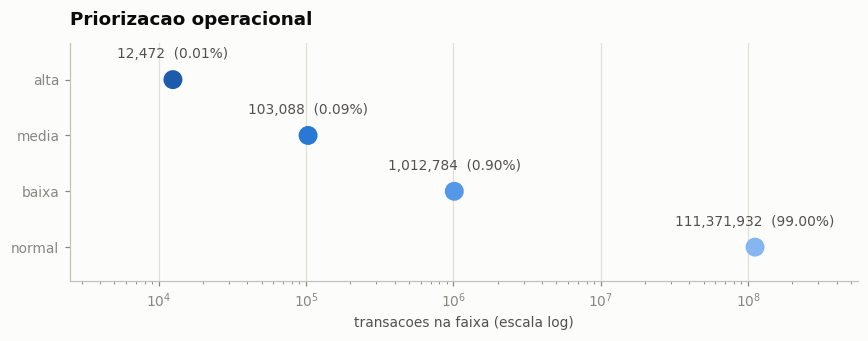

In [ ]:
RAMPA = {"normal": "#86b6ef", "baixa": "#5598e7", "media": "#2a78d6", "alta": "#1c5cab"}
ordem = [o for o in ["normal", "baixa", "media", "alta"]
         if o in set(prioridade["prioridade"])]
d = prioridade.set_index("prioridade").reindex(ordem).reset_index()
n = d["transacoes"].astype(float)

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.scatter(n, d["prioridade"], s=130, zorder=3, clip_on=False,
           color=[RAMPA[p] for p in d["prioridade"]])
for y, (v, pct) in enumerate(zip(n, d["pct"])):
    ax.annotate(f"{int(v):,}  ({pct:.2f}%)", (v, y), textcoords="offset points",
                xytext=(0, 14), ha="center", fontsize=9, color=TINTA)

ax.set_xscale("log")
ax.set_xlim(n.min() / 5, n.max() * 5)
ax.set_ylim(-0.6, len(d) - 0.35)
ax.set_xlabel("transacoes na faixa (escala log)")
ax.set_title("Priorizacao operacional", loc="left")
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

---

## Apêndice — o que o pipeline custou

Lê `INFORMATION_SCHEMA`, que cobra o mínimo de 10 MB por consulta.

In [ ]:
custos = executar("""
SELECT
  FORMAT_TIMESTAMP('%Y-%m-%d', creation_time)            AS dia,
  COUNT(*)                                               AS jobs,
  ROUND(SUM(total_bytes_billed) / POW(1024, 3), 1)       AS gb_faturados,
  ROUND(SUM(total_slot_ms) / 1000 / 60, 1)               AS slot_minutos,
  ROUND(SUM(TIMESTAMP_DIFF(end_time, start_time, SECOND)) / 60, 1) AS minutos
FROM `region-us`.INFORMATION_SCHEMA.JOBS_BY_PROJECT
WHERE creation_time >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 60 DAY)
  AND job_type = 'QUERY' AND state = 'DONE'
  AND error_result IS NULL AND parent_job_id IS NULL
GROUP BY dia
ORDER BY dia
""", "[apendice] custo por dia")

display(custos)
print(f"\ntotal faturado no periodo: {custos['gb_faturados'].sum():,.1f} GB")

[apendice] custo por dia  4 linhas  |  0.02 GB faturados


,dia,jobs,gb_faturados,slot_minutos,minutos
0,2026-09-07,18,234.4,447.1,0.8
1,2026-09-08,28,685.7,2423.0,3.9
2,2026-09-09,72,1483.8,8662.1,28.1
3,2026-09-10,24,315.0,667.8,9.0



total faturado no periodo: 2,718.9 GB
